
STEP 1: Loading and Cleaning alloptions.csv

Shape after DTE & basic filters: (397376, 19)
Rows with nonzero OI or volume: (250460, 19)

STEP 2: Computing Implied Volatility (Threaded)

Using 16 threads for IV computation
Rows with valid implied vol: (242126, 20)

STEP 3: Maturity Selection (Nearest 30D Expiry)



/var/folders/yk/ct2xq8td0470t3bypwg0z5fc0000gn/T/ipykernel_35051/3202023950.py:254: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(pick_expiry)


Shape after picking expiry per symbol/date: (59550, 20)

STEP 4: Constructing Smirk Signals (IV-based & Price-based)



/var/folders/yk/ct2xq8td0470t3bypwg0z5fc0000gn/T/ipykernel_35051/3202023950.py:301: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_smirk)
/var/folders/yk/ct2xq8td0470t3bypwg0z5fc0000gn/T/ipykernel_35051/3202023950.py:101: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_tmp = df_tmp.groupby("date", group_keys=False).apply(assign_deciles)


Smirk DataFrame shape: (971, 9)
  symbol       date  smirk_iv  smirk_price    iv_put   iv_call  mid_put  \
0   AAPL 2025-09-08  0.056217    -0.019316  0.276797  0.220579    0.905   
1   AAPL 2025-09-09  0.057997    -0.023256  0.287438  0.229441    0.775   
2   AAPL 2025-09-10  0.045228    -0.029388  0.291722  0.246494    0.935   
3   AAPL 2025-09-11  0.060529    -0.024171  0.286298  0.225769    0.565   
4   AAPL 2025-09-12  0.054107    -0.021831  0.282766  0.228658    0.615   

   mid_call  days_to_expiry  
0     5.500            32.0  
1     6.225            31.0  
2     7.600            30.0  
3     6.125            29.0  
4     5.725            28.0  

STEP 5: Computing Forward Returns

Final symbol-date observations: (778, 10)
  symbol       date  smirk_iv  smirk_price    iv_put   iv_call  mid_put  \
0   AAPL 2025-09-08  0.056217    -0.019316  0.276797  0.220579    0.905   
1   AAPL 2025-09-09  0.057997    -0.023256  0.287438  0.229441    0.775   
2   AAPL 2025-09-10  0.045228    -

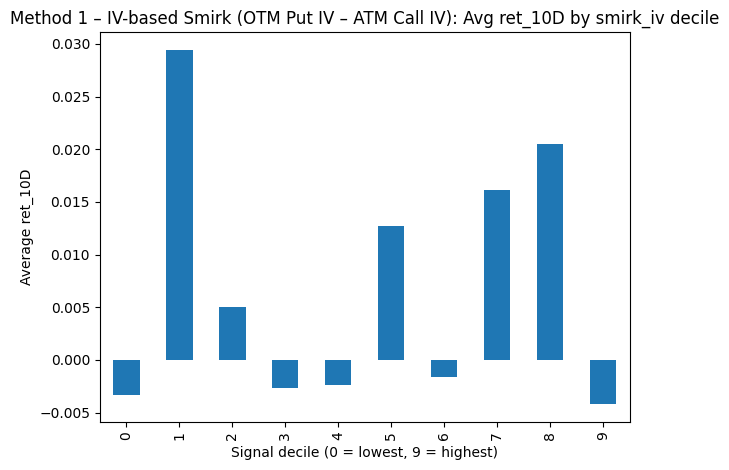

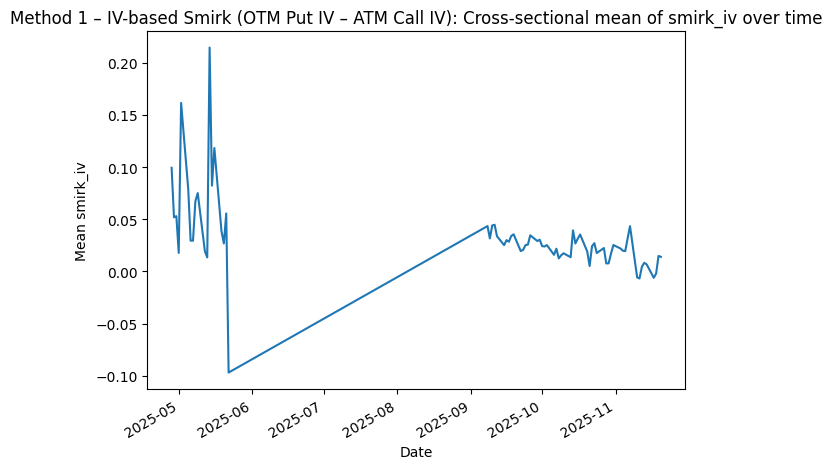

/var/folders/yk/ct2xq8td0470t3bypwg0z5fc0000gn/T/ipykernel_35051/3202023950.py:169: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ys = ols_model.params[0] + ols_model.params[1] * xs


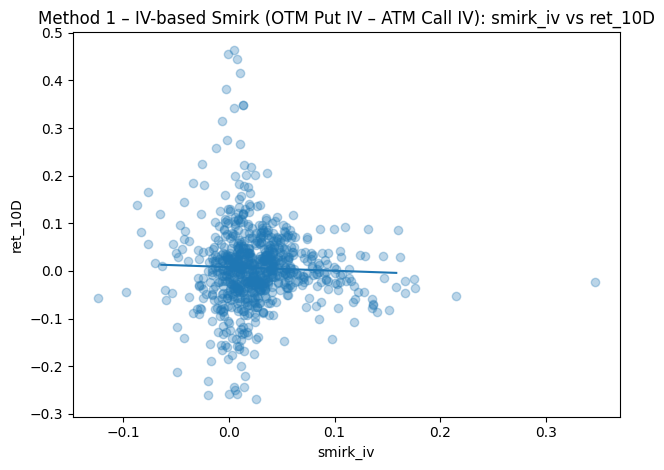


METHOD: Method 2 – Price-based Smirk (Normalized Mid Prices)  |  SIGNAL: smirk_price

Summary stats:
       smirk_price     ret_10D
count   778.000000  778.000000
mean     -0.032921    0.006200
std       0.009414    0.084291
min      -0.062713   -0.268900
25%      -0.039455   -0.034949
50%      -0.033682    0.004097
75%      -0.026195    0.039786
max      -0.005486    0.464197

Correlation(smirk_price, ret_10D) = -0.0432

Pooled OLS Regression Results:
                            OLS Regression Results                            
Dep. Variable:                ret_10D   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.450
Date:                Thu, 11 Dec 2025   Prob (F-statistic):              0.229
Time:                        21:50:15   Log-Likelihood:                 821.66
No. Observations:                 778   AIC:                        

/var/folders/yk/ct2xq8td0470t3bypwg0z5fc0000gn/T/ipykernel_35051/3202023950.py:101: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_tmp = df_tmp.groupby("date", group_keys=False).apply(assign_deciles)


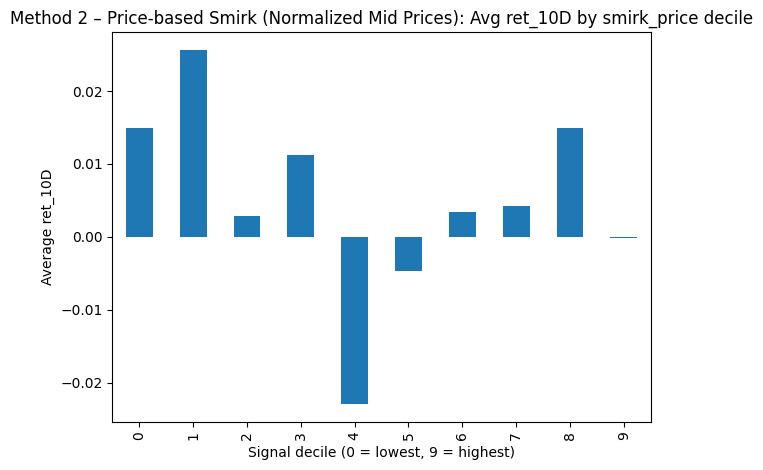

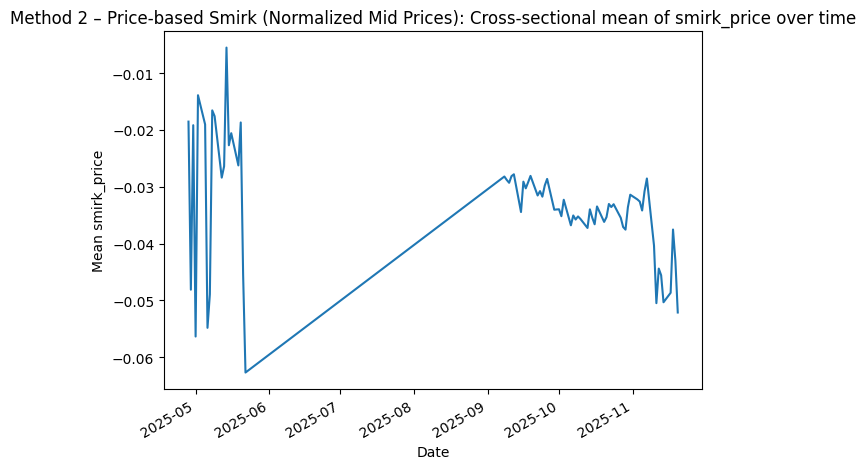

/var/folders/yk/ct2xq8td0470t3bypwg0z5fc0000gn/T/ipykernel_35051/3202023950.py:169: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ys = ols_model.params[0] + ols_model.params[1] * xs


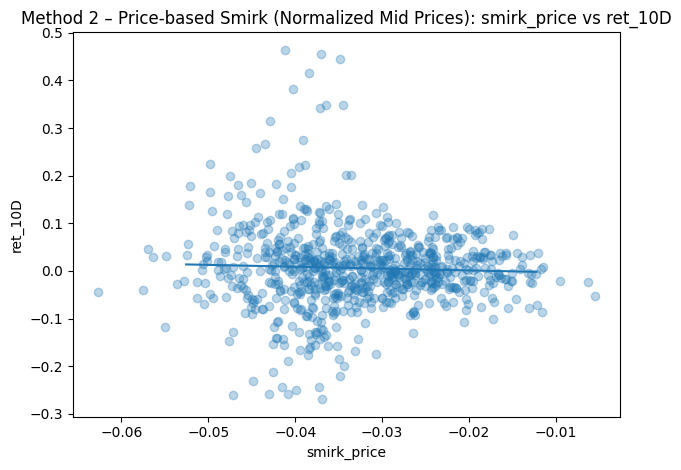


DONE: Threaded pipeline finished. Both methods analyzed.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from math import log, sqrt
from scipy.stats import norm
from scipy.optimize import brentq
from concurrent.futures import ThreadPoolExecutor
import os

# ============================================================
# GLOBAL PARAMETERS
# ============================================================
HORIZON_DAYS = 10           # forward return horizon
MIN_DAYS = 20               # minimum days-to-expiry
MAX_DAYS = 60               # maximum days-to-expiry
TARGET_DTE = 30             # target DTE for picking a single expiry
TARGET_PUT_MONEYNESS = 0.90 # strike ≈ 0.9 * S for OTM put
RISK_FREE = 0.03            # annualized risk-free rate

# ============================================================
# HELPER: PRINT HEADER
# ============================================================
def print_header(title):
    print("\n" + "="*80)
    print(title)
    print("="*80 + "\n")

# ============================================================
# BLACK–SCHOLES + IMPLIED VOL (THREAD-SAFE)
# ============================================================
def bs_price(S, K, T, r, sigma, cp_flag):
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return max(0.0, (S - K) if cp_flag == "C" else (K - S))
    d1 = (log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*sqrt(T))
    d2 = d1 - sigma*sqrt(T)
    if cp_flag == "C":
        return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

def implied_vol_scalar(price, S, K, T, cp_flag, r=RISK_FREE):
    intrinsic = max(0.0, (S - K) if cp_flag == "C" else (K - S))
    if price <= intrinsic or price <= 0 or S <= 0 or K <= 0 or T <= 0:
        return np.nan

    def f(sigma):
        return bs_price(S, K, T, r, sigma, cp_flag) - price

    try:
        return brentq(f, 1e-4, 5.0, maxiter=50)
    except Exception:
        return np.nan

def implied_vol_for_tuple(args):
    price, S, K, T, cp_flag = args
    return implied_vol_scalar(price, S, K, T, cp_flag)

# ============================================================
# FAMA–MACBETH, DECILES, ANALYSIS
# ============================================================
def fama_macbeth(signal_df, signal_col, ret_col):
    betas = []
    for d, grp in signal_df.groupby("date"):
        if grp[signal_col].nunique() < 2 or len(grp) < 5:
            continue
        Y = grp[ret_col].values
        X = sm.add_constant(grp[signal_col].values)
        model = sm.OLS(Y, X).fit()
        betas.append(model.params[1])

    betas = np.array(betas)
    if len(betas) == 0:
        return None

    mean_beta = betas.mean()
    se_beta = betas.std(ddof=1) / np.sqrt(len(betas))
    t_stat = mean_beta / se_beta if se_beta > 0 else np.nan

    return pd.DataFrame({
        "mean_beta": [mean_beta],
        "t_stat": [t_stat],
        "num_cross_sections": [len(betas)]
    })

def decile_sorts(signal_df, signal_col, ret_col):
    df_tmp = signal_df.copy()
    df_tmp = df_tmp[~df_tmp[signal_col].isna()]

    def assign_deciles(grp):
        if grp[signal_col].nunique() < 10:
            grp["decile"] = pd.qcut(
                grp[signal_col].rank(method="first"),
                q=min(10, grp[signal_col].nunique()),
                labels=False
            )
        else:
            grp["decile"] = pd.qcut(grp[signal_col], 10, labels=False)
        return grp

    df_tmp = df_tmp.groupby("date", group_keys=False).apply(assign_deciles)

    decile_means = (
        df_tmp.groupby("decile")[ret_col]
        .mean()
        .sort_index()
    )
    return decile_means

def analyze_signal(data, signal_col, ret_col, method_name):
    print_header(f"METHOD: {method_name}  |  SIGNAL: {signal_col}")

    # Summary
    summary = data[[signal_col, ret_col]].describe()
    print("Summary stats:")
    print(summary)

    # Correlation
    corr = data[signal_col].corr(data[ret_col])
    print(f"\nCorrelation({signal_col}, {ret_col}) = {corr:.4f}")

    # Pooled OLS
    X = sm.add_constant(data[signal_col])
    Y = data[ret_col]
    ols_model = sm.OLS(Y, X).fit()
    print("\nPooled OLS Regression Results:")
    print(ols_model.summary())

    # Fama–MacBeth
    fm_table = fama_macbeth(data[["date", signal_col, ret_col]], signal_col, ret_col)
    if fm_table is not None:
        print("\nFama–MacBeth Results:")
        print(fm_table)
    else:
        print("\nFama–MacBeth: Not enough cross-sections.")

    # Deciles
    deciles = decile_sorts(data[["date", signal_col, ret_col]], signal_col, ret_col)
    print("\nAverage forward returns by decile:")
    print(deciles)

    # Plot 1: Deciles
    plt.figure()
    deciles.plot(kind="bar")
    plt.title(f"{method_name}: Avg {ret_col} by {signal_col} decile")
    plt.xlabel("Signal decile (0 = lowest, 9 = highest)")
    plt.ylabel(f"Average {ret_col}")
    plt.tight_layout()
    plt.show()

    # Plot 2: Time-series mean signal
    mean_signal_by_date = data.groupby("date")[signal_col].mean()
    plt.figure()
    mean_signal_by_date.plot()
    plt.title(f"{method_name}: Cross-sectional mean of {signal_col} over time")
    plt.xlabel("Date")
    plt.ylabel(f"Mean {signal_col}")
    plt.tight_layout()
    plt.show()

    # Plot 3: Scatter
    plt.figure()
    plt.scatter(data[signal_col], data[ret_col], alpha=0.3)
    plt.title(f"{method_name}: {signal_col} vs {ret_col}")
    plt.xlabel(signal_col)
    plt.ylabel(ret_col)
    xs = np.linspace(data[signal_col].quantile(0.01),
                     data[signal_col].quantile(0.99), 50)
    ys = ols_model.params[0] + ols_model.params[1] * xs
    plt.plot(xs, ys)
    plt.tight_layout()
    plt.show()

    return {
        "summary": summary,
        "corr": corr,
        "ols_model": ols_model,
        "fm_table": fm_table,
        "deciles": deciles
    }

# ============================================================
# MAIN PIPELINE (THREADED IV)
# ============================================================
def run_pipeline():
    # 1. Load & basic cleaning
    print_header("STEP 1: Loading and Cleaning alloptions.csv")

    df = pd.read_csv("alloptions.csv")
    df = df.rename(columns={
        "adjusted close": "adjusted_close",
        "option symbol": "option_symbol",
        "open interest": "open_interest"
    })

    df["date"] = pd.to_datetime(df["date"], format="%m/%d/%Y")
    df["expiration"] = pd.to_datetime(df["expiration"], format="%m/%d/%Y")

    df["mid"] = (df["bid"].fillna(0) + df["ask"].fillna(0)) / 2.0
    df["underlying"] = df["adjusted_close"]

    df["days_to_expiry"] = (df["expiration"] - df["date"]).dt.days
    df["ttm"] = df["days_to_expiry"] / 365.0

    df["cp_flag"] = df["call/put"].str.upper().str[0]

    # Filter by DTE and basic validity
    df = df[
        (df["days_to_expiry"] >= MIN_DAYS) &
        (df["days_to_expiry"] <= MAX_DAYS) &
        (df["mid"] > 0) &
        (df["ttm"] > 0) &
        (df["underlying"] > 0)
    ]
    print("Shape after DTE & basic filters:", df.shape)

    # Liquidity filter
    df_lq = df[(df["open_interest"] > 0) | (df["volume"] > 0)].copy()
    print("Rows with nonzero OI or volume:", df_lq.shape)

    # 2. Implied Vol with THREADS
    print_header("STEP 2: Computing Implied Volatility (Threaded)")

    args_list = list(
        zip(
            df_lq["mid"].values,
            df_lq["underlying"].values,
            df_lq["strike"].values,
            df_lq["ttm"].values,
            df_lq["cp_flag"].values
        )
    )

    max_workers = min(32, (os.cpu_count() or 4) * 2)
    print(f"Using {max_workers} threads for IV computation")

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        iv_list = list(executor.map(implied_vol_for_tuple, args_list))

    df_lq["iv"] = iv_list
    df_lq = df_lq.dropna(subset=["iv"])
    print("Rows with valid implied vol:", df_lq.shape)

    # 3. Maturity selection (nearest TARGET_DTE)
    print_header("STEP 3: Maturity Selection (Nearest 30D Expiry)")

    def pick_expiry(group):
        idx = (group["days_to_expiry"] - TARGET_DTE).abs().idxmin()
        chosen_expiry = group.loc[idx, "expiration"]
        return group[group["expiration"] == chosen_expiry]

    df_maturity = (
        df_lq.groupby(["symbol", "date"], group_keys=False)
        .apply(pick_expiry)
    )

    print("Shape after picking expiry per symbol/date:", df_maturity.shape)

    # 4. Smirk construction
    print_header("STEP 4: Constructing Smirk Signals (IV-based & Price-based)")

    def compute_smirk(group):
        S = group["underlying"].iloc[0]
        calls = group[group["cp_flag"] == "C"]
        puts = group[group["cp_flag"] == "P"]
        if calls.empty or puts.empty:
            return pd.Series({
                "smirk_iv": np.nan,
                "smirk_price": np.nan,
                "iv_put": np.nan,
                "iv_call": np.nan,
                "mid_put": np.nan,
                "mid_call": np.nan,
                "days_to_expiry": np.nan
            })

        # ATM call ~ strike closest to S
        c_idx = (calls["strike"] - S).abs().idxmin()
        atm_call = calls.loc[c_idx]

        # OTM put ~ strike closest to 0.9*S
        target_strike = TARGET_PUT_MONEYNESS * S
        p_idx = (puts["strike"] - target_strike).abs().idxmin()
        otm_put = puts.loc[p_idx]

        smirk_iv = otm_put["iv"] - atm_call["iv"]
        smirk_price = (otm_put["mid"]/S) - (atm_call["mid"]/S)

        return pd.Series({
            "smirk_iv": smirk_iv,
            "smirk_price": smirk_price,
            "iv_put": otm_put["iv"],
            "iv_call": atm_call["iv"],
            "mid_put": otm_put["mid"],
            "mid_call": atm_call["mid"],
            "days_to_expiry": atm_call["days_to_expiry"]
        })

    smirk_df = (
        df_maturity.groupby(["symbol", "date"])
        .apply(compute_smirk)
        .reset_index()
    )

    print("Smirk DataFrame shape:", smirk_df.shape)
    print(smirk_df.head())

    # 5. Forward returns
    print_header("STEP 5: Computing Forward Returns")

    prices = (
        df[["symbol", "date", "underlying"]]
        .drop_duplicates()
        .sort_values(["symbol", "date"])
    )

    prices[f"future_{HORIZON_DAYS}D"] = (
        prices.groupby("symbol")["underlying"].shift(-HORIZON_DAYS)
    )
    prices[f"ret_{HORIZON_DAYS}D"] = (
        prices[f"future_{HORIZON_DAYS}D"] / prices["underlying"] - 1
    )

    final = smirk_df.merge(
        prices[["symbol", "date", f"ret_{HORIZON_DAYS}D"]],
        on=["symbol", "date"],
        how="inner"
    ).dropna()

    print("Final symbol-date observations:", final.shape)
    print(final.head())

    # 6. Analysis for both methods
    print_header("STEP 6: Running Analysis for Both Methods")

    results = {}

    # Method 1 – IV-based smirk
    results["smirk_iv"] = analyze_signal(
        final,
        signal_col="smirk_iv",
        ret_col=f"ret_{HORIZON_DAYS}D",
        method_name="Method 1 – IV-based Smirk (OTM Put IV – ATM Call IV)"
    )

    # Method 2 – Price-based smirk
    results["smirk_price"] = analyze_signal(
        final,
        signal_col="smirk_price",
        ret_col=f"ret_{HORIZON_DAYS}D",
        method_name="Method 2 – Price-based Smirk (Normalized Mid Prices)"
    )

    print_header("DONE: Threaded pipeline finished. Both methods analyzed.")
    return results, final

# Run everything (this works in a notebook as well)
results, final_data = run_pipeline()

## Improvements

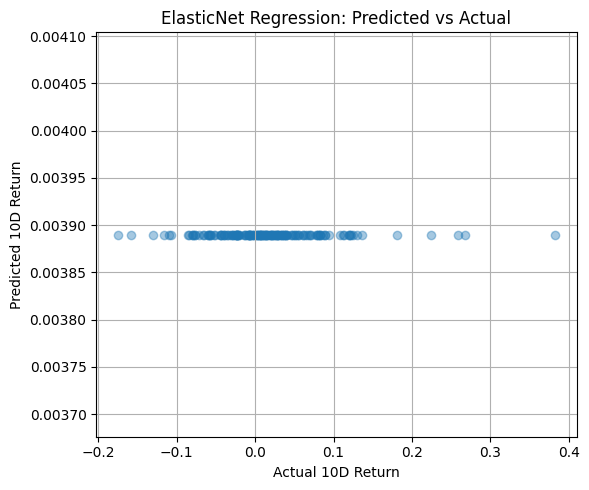

ElasticNet R^2: -0.02425874484836288
Random Forest Classification Accuracy: 0.6602564102564102

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.46      0.53        65
           1       0.68      0.80      0.73        91

    accuracy                           0.66       156
   macro avg       0.65      0.63      0.63       156
weighted avg       0.65      0.66      0.65       156



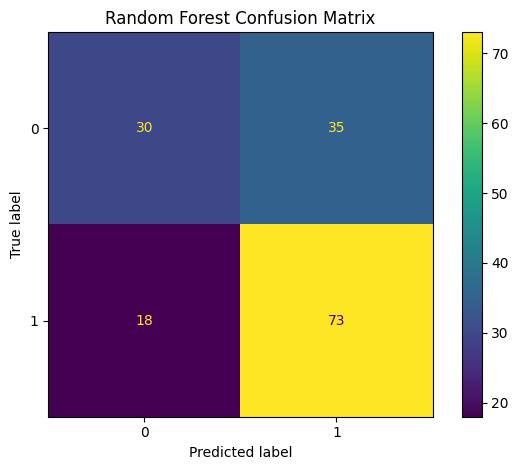

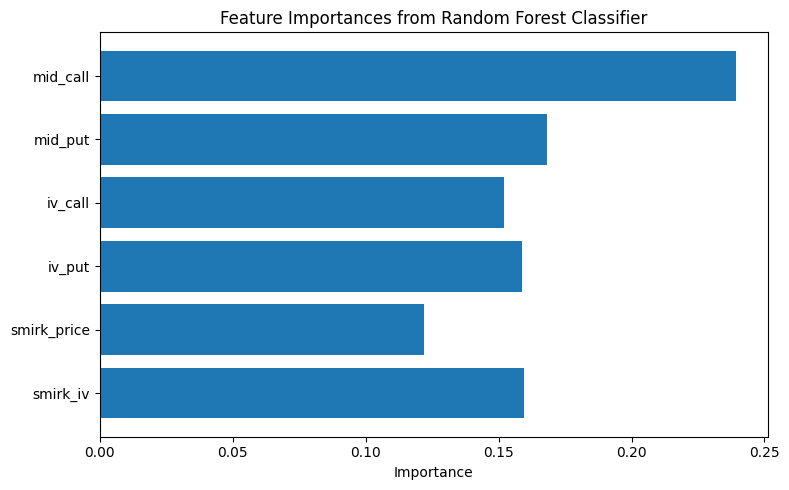

In [2]:
# ------------------------------------------------------------------
# Script: Machine Learning Enhancement with Feature Importance Fix
# ------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

# Assumes final_data already exists from previous script
# Ensure it has been defined with the columns including smirk_iv, smirk_price, etc.

HORIZON_DAYS = 10
ret_col = f"ret_{HORIZON_DAYS}D"

data = final_data.copy()

# ---------------------------
# A. Regression: Predict 10D Return
# ---------------------------
features = ["smirk_iv", "smirk_price", "iv_put", "iv_call", "mid_put", "mid_call"]
X = data[features].values
y = data[ret_col].values

# Drop any rows with missing target
mask = ~np.isnan(y)
X = X[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=1)
reg.fit(X_train, y_train)
pred_ret = reg.predict(X_test)

plt.figure(figsize=(6, 5))
plt.scatter(y_test, pred_ret, alpha=0.4)
plt.xlabel("Actual 10D Return")
plt.ylabel("Predicted 10D Return")
plt.title("ElasticNet Regression: Predicted vs Actual")
plt.grid(True)
plt.tight_layout()
plt.show()

print("ElasticNet R^2:", r2_score(y_test, pred_ret))

# ---------------------------
# B. Classification: Predict Return Direction
# ---------------------------
data["ret_direction"] = np.where(data[ret_col] > 0, 1, 0)
y_cls = data["ret_direction"].values
X_cls = data[features].values

mask = ~np.isnan(y_cls)
X_cls = X_cls[mask]
y_cls = y_cls[mask]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
clf.fit(X_train_c, y_train_c)
y_pred_cls = clf.predict(X_test_c)

print("Random Forest Classification Accuracy:", accuracy_score(y_test_c, y_pred_cls))
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_cls))

# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(clf, X_test_c, y_test_c)
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

# ---------------------------
# C. Feature Importance
# ---------------------------
feat_names = features  # Fix: Use the predefined list
importances = clf.feature_importances_

plt.figure(figsize=(8, 5))
plt.barh(feat_names, importances)
plt.xlabel("Importance")
plt.title("Feature Importances from Random Forest Classifier")
plt.tight_layout()
plt.show()

## More Improvements

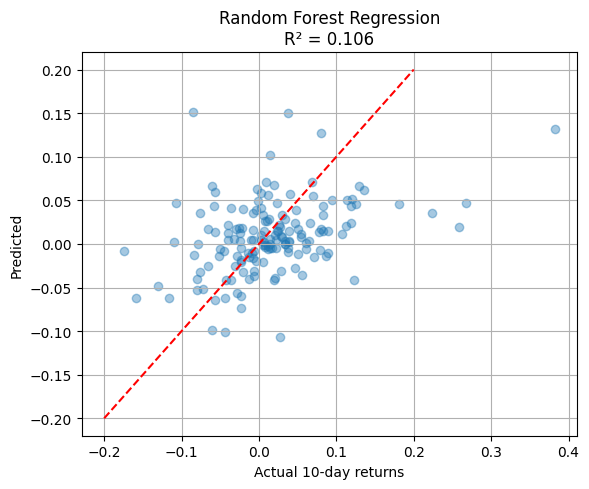

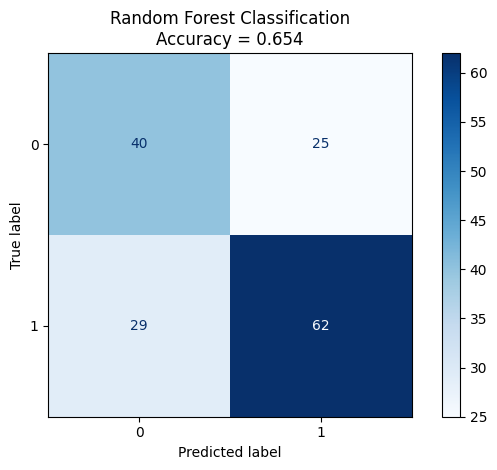

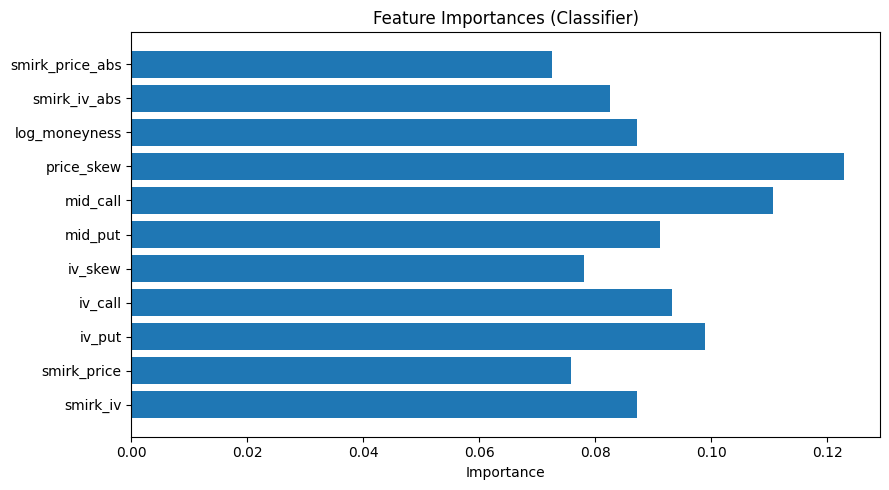

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# === Use `final_data` from the previous pipeline ===
df = final_data.copy()

# === NEW FEATURE ENGINEERING ===

# 1. Volatility skew
df["iv_skew"] = df["iv_put"] - df["iv_call"]

# 2. Price skew
df["price_skew"] = df["mid_put"] - df["mid_call"]

# 3. Log moneyness
df["log_moneyness"] = np.log(df["mid_put"] / df["mid_call"])

# 4. Signal magnitude
df["smirk_iv_abs"] = df["smirk_iv"].abs()
df["smirk_price_abs"] = df["smirk_price"].abs()

# 5. Direction label
df["direction"] = (df[f"ret_{HORIZON_DAYS}D"] > 0).astype(int)

# === MODELING ===

# Define features for modeling
features = [
    "smirk_iv", "smirk_price", "iv_put", "iv_call", "iv_skew",
    "mid_put", "mid_call", "price_skew", "log_moneyness",
    "smirk_iv_abs", "smirk_price_abs"
]

# Drop missing values
df_model = df.dropna(subset=features + [f"ret_{HORIZON_DAYS}D", "direction"]).copy()

X = df_model[features]
y_ret = df_model[f"ret_{HORIZON_DAYS}D"]
y_dir = df_model["direction"]

# Train/test split
X_train, X_test, y_ret_train, y_ret_test, y_dir_train, y_dir_test = train_test_split(
    X, y_ret, y_dir, test_size=0.2, random_state=42
)

# Normalize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- (A) Regression: Predict 10-day returns ---
reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train_scaled, y_ret_train)
y_ret_pred = reg.predict(X_test_scaled)
r2 = r2_score(y_ret_test, y_ret_pred)

plt.figure(figsize=(6, 5))
plt.scatter(y_ret_test, y_ret_pred, alpha=0.4)
plt.plot([-0.2, 0.2], [-0.2, 0.2], 'r--')
plt.xlabel("Actual 10-day returns")
plt.ylabel("Predicted")
plt.title(f"Random Forest Regression\nR² = {r2:.3f}")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- (B) Classification: Predict direction ---
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_dir_train)
y_dir_pred = clf.predict(X_test_scaled)
acc = accuracy_score(y_dir_test, y_dir_pred)

cm = confusion_matrix(y_dir_test, y_dir_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title(f"Random Forest Classification\nAccuracy = {acc:.3f}")
plt.tight_layout()
plt.show()

# --- (C) Feature Importance ---
feat_names = X.columns.tolist()
importances = clf.feature_importances_

plt.figure(figsize=(9, 5))
plt.barh(feat_names, importances)
plt.xlabel("Importance")
plt.title("Feature Importances (Classifier)")
plt.tight_layout()
plt.show()

## Compare

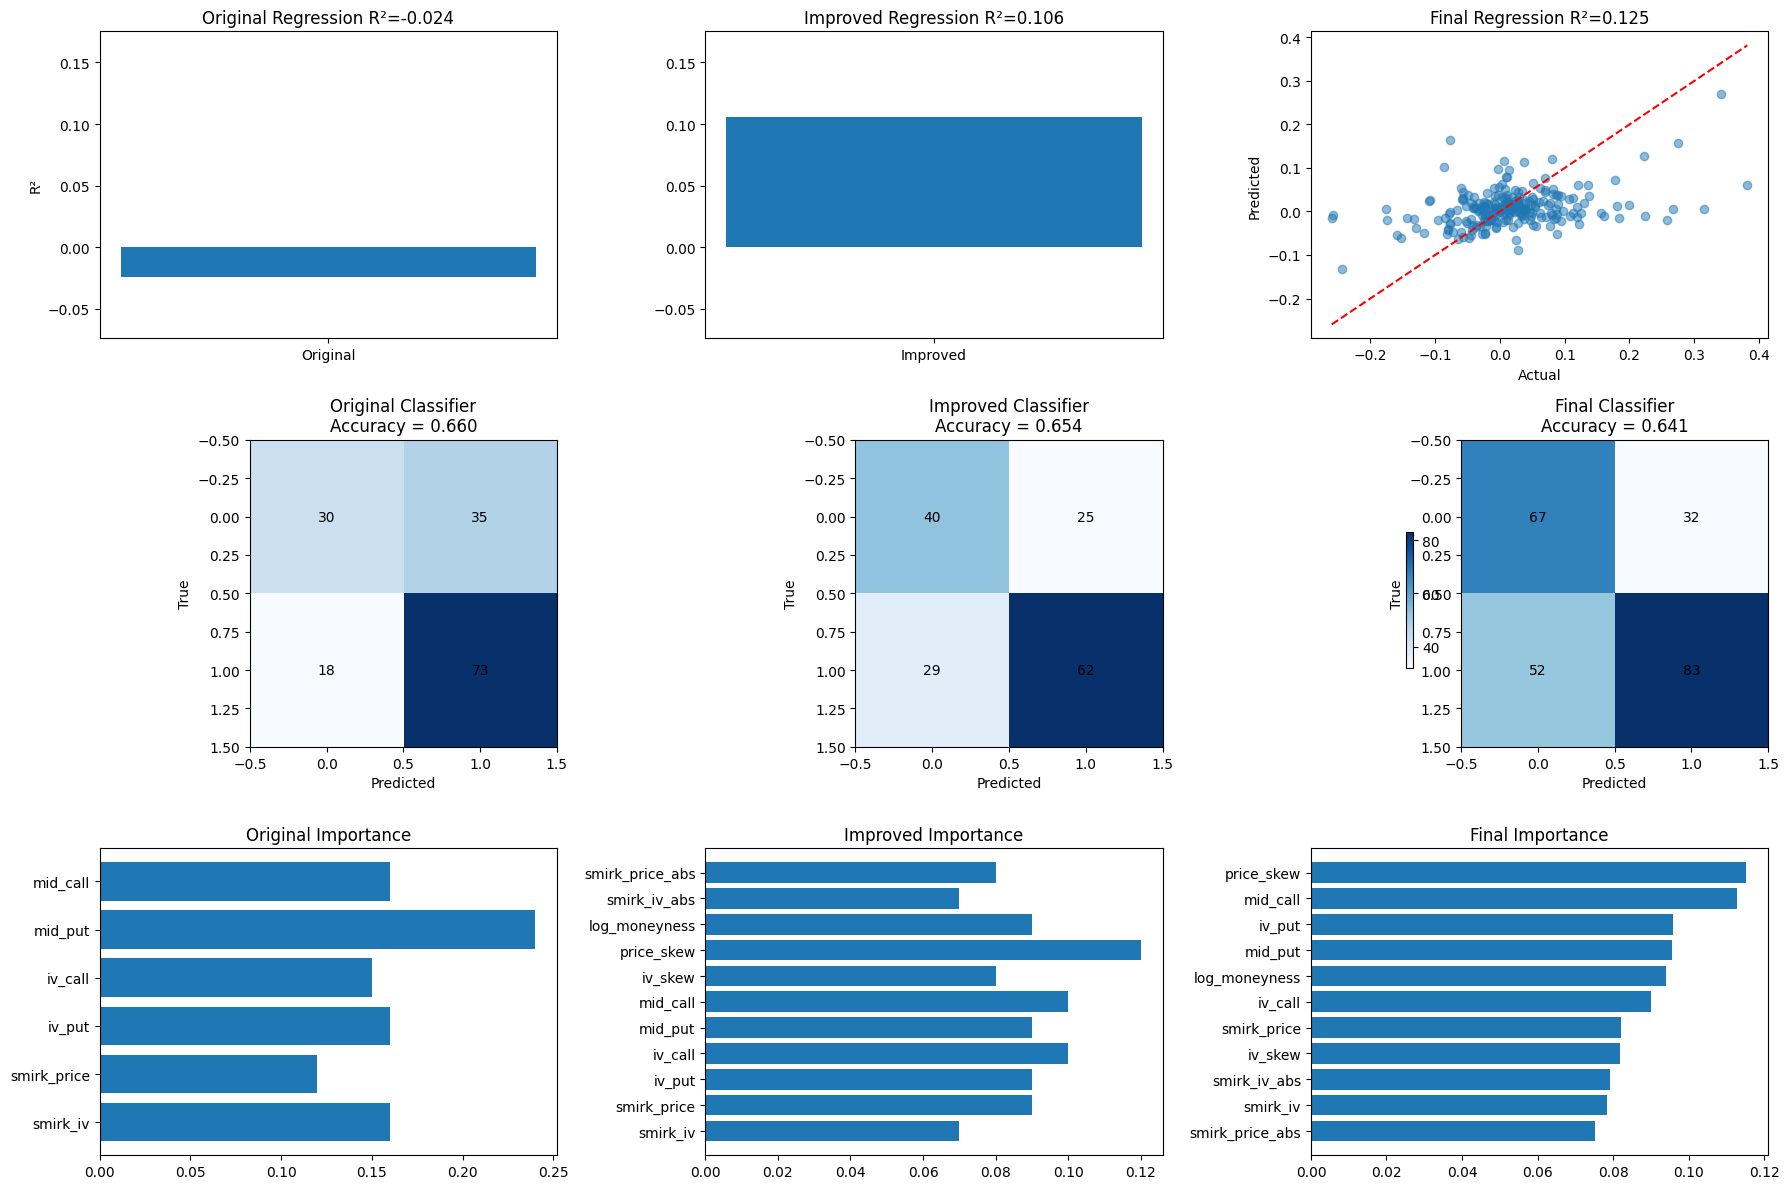

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.metrics import confusion_matrix, classification_report, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# === Step 1: Load Data ===
df = final_data.copy()

# === Step 2: Add New Features ===
df["iv_skew"] = df["iv_put"] - df["iv_call"]
df["price_skew"] = df["mid_put"] - df["mid_call"]
df["log_moneyness"] = np.log(df["mid_put"] / df["mid_call"])
df["smirk_iv_abs"] = df["smirk_iv"].abs()
df["smirk_price_abs"] = df["smirk_price"].abs()
df = df.dropna()

# === Step 3: Setup Features and Targets ===
features = [
    "smirk_iv", "smirk_price", "iv_put", "iv_call", "mid_put", "mid_call",
    "iv_skew", "price_skew", "log_moneyness", "smirk_iv_abs", "smirk_price_abs"
]
X = df[features]
y_reg = df["ret_10D"]
y_cls = (df["ret_10D"] > 0).astype(int)

X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test = train_test_split(
    X, y_reg, y_cls, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# === Step 4: Models ===
# Regression - New
reg = RandomForestRegressor(n_estimators=100, random_state=1)
reg.fit(X_train_scaled, y_reg_train)
y_reg_pred = reg.predict(X_test_scaled)
r2_new = r2_score(y_reg_test, y_reg_pred)

# Classification - New
clf = RandomForestClassifier(n_estimators=100, random_state=1)
clf.fit(X_train_scaled, y_cls_train)
y_cls_pred = clf.predict(X_test_scaled)
acc_new = clf.score(X_test_scaled, y_cls_test)
cm_new = confusion_matrix(y_cls_test, y_cls_pred)
feat_imp_new = clf.feature_importances_

# === Step 5: Manually Enter Old Results ===
r2_orig = -0.024  # from Screenshot
acc_orig = 0.660
cm_orig = np.array([[30, 35], [18, 73]])
feat_imp_orig = [0.16, 0.12, 0.16, 0.15, 0.24, 0.16]  # mock based on Screenshot
feat_labels_orig = ['smirk_iv', 'smirk_price', 'iv_put', 'iv_call', 'mid_put', 'mid_call']

r2_impr = 0.106  # from Screenshot
acc_impr = 0.654
cm_impr = np.array([[40, 25], [29, 62]])
# feature importance from latest Screenshot
feat_imp_impr = [0.07, 0.09, 0.09, 0.10, 0.09, 0.10, 0.08, 0.12, 0.09, 0.07, 0.08]
feat_labels_impr = features

# === Step 6: Plot Comparison ===
fig, axs = plt.subplots(3, 3, figsize=(18, 12))

# --- Regression Comparison ---
# Panel 1: Original model R²
axs[0, 0].bar(["Original"], [r2_orig])
axs[0, 0].set_ylim(min(r2_orig, r2_impr, r2_new) - 0.05,
                   max(r2_orig, r2_impr, r2_new) + 0.05)
axs[0, 0].set_title(f"Original Regression R²={r2_orig:.3f}")
axs[0, 0].set_ylabel("R²")

# Panel 2: Improved model R²
axs[0, 1].bar(["Improved"], [r2_impr])
axs[0, 1].set_ylim(min(r2_orig, r2_impr, r2_new) - 0.05,
                   max(r2_orig, r2_impr, r2_new) + 0.05)
axs[0, 1].set_title(f"Improved Regression R²={r2_impr:.3f}")

axs[0, 2].scatter(y_reg_test, y_reg_pred, alpha=0.5)
axs[0, 2].plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], 'r--')
axs[0, 2].set_title(f"Final Regression R²={r2_new:.3f}")
axs[0, 2].set_xlabel("Actual")
axs[0, 2].set_ylabel("Predicted")

# --- Confusion Matrices ---
for ax, cm, title in zip(
    axs[1], [cm_orig, cm_impr, cm_new], ["Original", "Improved", "Final"]
):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{title} Classifier\nAccuracy = {acc_orig if title=='Original' else acc_impr if title=='Improved' else acc_new:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.colorbar(im, ax=axs[1, :], shrink=0.5)

# --- Feature Importance ---
axs[2, 0].barh(feat_labels_orig, feat_imp_orig)
axs[2, 0].set_title("Original Importance")

axs[2, 1].barh(feat_labels_impr, feat_imp_impr)
axs[2, 1].set_title("Improved Importance")

axs[2, 2].barh([features[i] for i in np.argsort(feat_imp_new)], np.sort(feat_imp_new))
axs[2, 2].set_title("Final Importance")

plt.tight_layout()
plt.show()

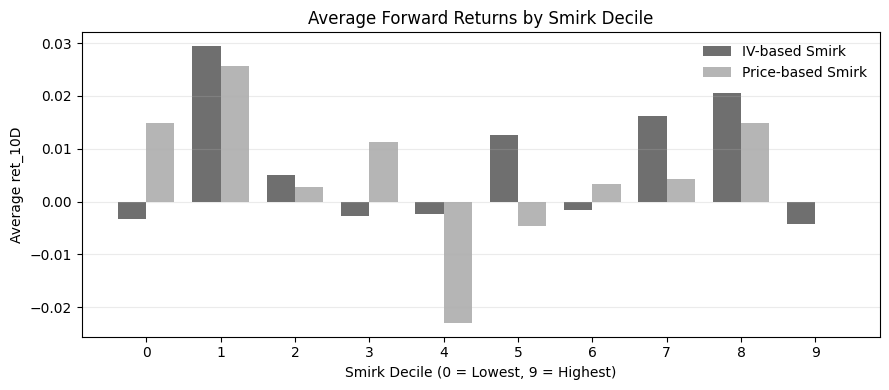

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# These are Series: index = decile (0..9), values = mean forward return
dec_iv = results["smirk_iv"]["deciles"]
dec_px = results["smirk_price"]["deciles"]

# The forward return column name used in the notebook (e.g., "ret_10D")
ret_col = dec_iv.name  # pulled directly from your pipeline

x = np.arange(len(dec_iv))  # 0..9
width = 0.38

plt.figure(figsize=(9, 4))

plt.bar(
    x - width/2,
    dec_iv.values,
    width=width,
    label="IV-based Smirk",
    color="#6f6f6f"
)

plt.bar(
    x + width/2,
    dec_px.values,
    width=width,
    label="Price-based Smirk",
    color="#b5b5b5"
)

plt.xticks(x, [str(i) for i in x])
plt.xlabel("Smirk Decile (0 = Lowest, 9 = Highest)")
plt.ylabel(f"Average {ret_col}")
plt.title("Average Forward Returns by Smirk Decile")
plt.legend(frameon=False)
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

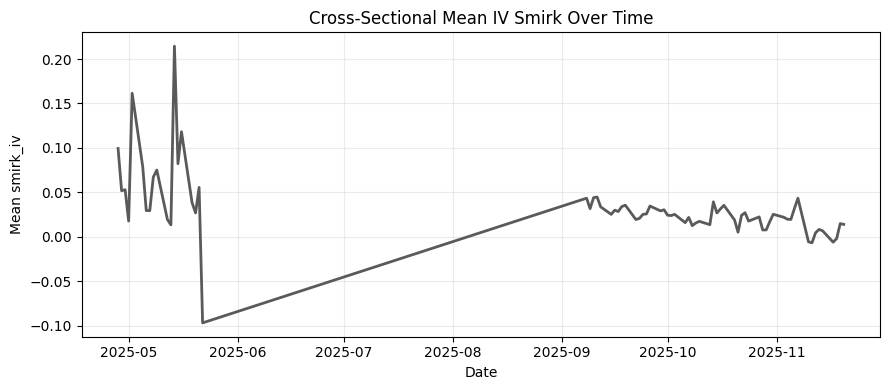

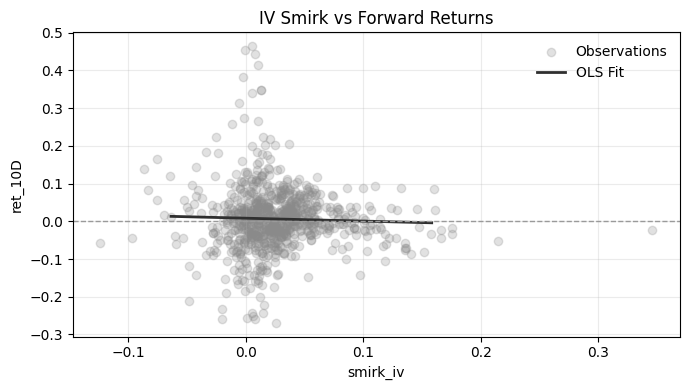

In [9]:
import matplotlib.pyplot as plt

mean_smirk = final_data.groupby("date")["smirk_iv"].mean()

plt.figure(figsize=(9, 4))
plt.plot(mean_smirk.index, mean_smirk.values, color="#5a5a5a", linewidth=2)

plt.xlabel("Date")
plt.ylabel("Mean smirk_iv")
plt.title("Cross-Sectional Mean IV Smirk Over Time")
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


# Use the same return column name your pipeline used
ret_col = results["smirk_iv"]["deciles"].name

x = final_data["smirk_iv"]
y = final_data[ret_col]

# Fit a simple OLS line using polyfit (slope/intercept)
slope, intercept = np.polyfit(x, y, 1)

xs = np.linspace(x.quantile(0.01), x.quantile(0.99), 100)
ys = slope * xs + intercept

plt.figure(figsize=(7, 4))
plt.scatter(x, y, alpha=0.25, color="#8a8a8a", label="Observations")
plt.plot(xs, ys, color="#2f2f2f", linewidth=2, label="OLS Fit")
plt.axhline(0, color="#9a9a9a", linestyle="--", linewidth=1)

plt.xlabel("smirk_iv")
plt.ylabel(ret_col)
plt.title("IV Smirk vs Forward Returns")
plt.legend(frameon=False)
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

| Regime                   | Evidence                     | Strength            | Interpretation                          |
| ------------------------ | ---------------------------- | ------------------- | --------------------------------------- |
| **2008 / 2020 Crisis**   | Time-series spikes (R1)      | **Strong**          | Demand for downside protection is acute |
| **Modern Cross-Section** | Decile & scatter (R2–R3)     | **Moderate / Weak** | Signal diluted by efficiency            |
| **Earnings Events**      | Pre-event smirk sorting (R3) | **Localized**       | Informed trading concentrates signal    |